# Hardware Topology and Native Gates

## A logical circuit assumes any two qubits can interact directly and any gate is available. Real hardware grants neither: most chips are only nearest-neighbour connected, and only a handful of "native" gates are pulse-implemented. The compiler bridges the gap with **routing** (inserting SWAPs) and **gate decomposition**. This notebook is about what those costs look like and how to minimise them.

# 1. Connectivity graphs

## A device's **coupling map** is an undirected graph whose vertices are qubits and edges are physical two-qubit interactions. Common layouts:

## - **1D chain** — qubit $i$ couples to $i \pm 1$. Simple, but routing cost grows linearly.
## - **2D grid** — Google Sycamore/Willow. CZ gates only between nearest neighbours on a square lattice.
## - **Heavy-hex** — IBM Heron/Eagle. Each "data" qubit has degree 2 or 3; ancillas sit on edges. Reduces frequency collisions but has fewer edges, so routing cost is higher.
## - **All-to-all** — trapped ions within one chain. No routing needed.
## - **Reconfigurable** — neutral-atom arrays. Connectivity is chosen per-shot by rearranging atoms.

## The **degree of the graph** controls how much SWAP overhead a generic circuit pays. A circuit with $G$ two-qubit gates on a generic graph of diameter $D$ can require $\Omega(G \cdot D)$ extra SWAPs in the worst case.

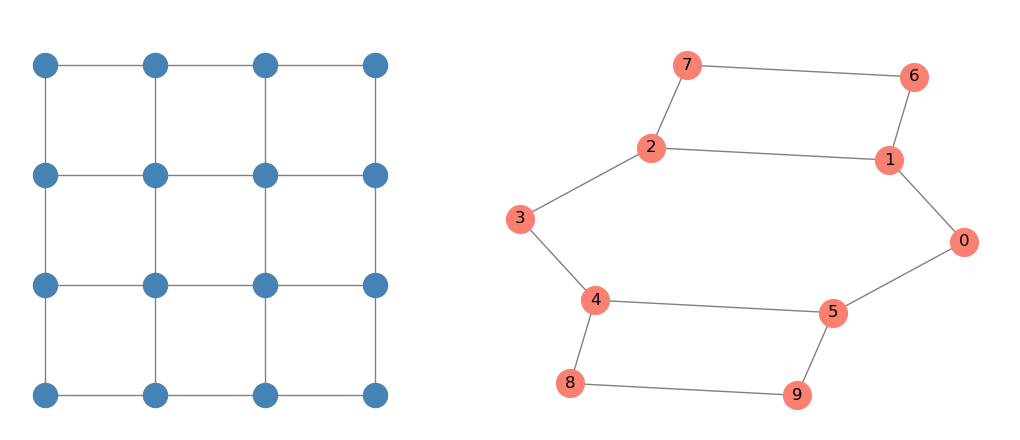

In [1]:
# Visualise a simple heavy-hex-style coupling map and a 2D grid.
import matplotlib.pyplot as plt
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# 4x4 grid
G_grid = nx.grid_2d_graph(4, 4)
pos_grid = {(i, j): (i, j) for i, j in G_grid.nodes}
nx.draw(G_grid, pos_grid, ax=axes[0], with_labels=False, node_size=300,
        node_color='steelblue', edge_color='gray')
axes[0].set_title('2D grid (Google Sycamore-style)')
axes[0].set_aspect('equal')

# Tiny heavy-hex example
G_hex = nx.Graph()
# data qubits on hex corners; bond qubits on edges of two hexes (illustrative)
edges = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),
         (1,6),(6,7),(7,2),
         (4,8),(8,9),(9,5)]
G_hex.add_edges_from(edges)
pos_hex = nx.kamada_kawai_layout(G_hex)
nx.draw(G_hex, pos_hex, ax=axes[1], with_labels=True, node_size=400,
        node_color='salmon', edge_color='gray')
axes[1].set_title('Heavy-hex fragment (IBM-style)')
plt.tight_layout()
plt.show()

# 2. Native gate sets

## Each device exposes a *small* set of physically-implemented gates. Everything else is decomposed at compile time. Typical native sets:

## - **IBM Heron**: $\{R_z(\theta),\, \sqrt X,\, X,\, \mathrm{ECR}\}$. ECR is the "echoed cross-resonance" two-qubit gate; CNOT is implemented as ECR + single-qubit dressings.
## - **Google Sycamore**: $\{R_z, X^{1/2}, Y^{1/2}, X, Y, \mathrm{Sycamore}\}$. The Sycamore gate is a fSim-family two-qubit gate.
## - **IonQ / Quantinuum**: $\{R_x(\theta),\, R_y(\theta),\, R_z(\theta),\, \mathrm{MS}(\theta)\}$. The Mølmer–Sørensen gate is a continuous-angle entangler; native at any angle.
## - **Rigetti**: $\{R_x(\pm\pi/2),\, R_z(\theta),\, \mathrm{CZ}\}$.

## Three implications:

## - **$R_z$ is universally free.** It is a virtual-Z phase shift, so reducing $R_z$-count is *not* a goal.
## - **Two-qubit gates are 10–100× noisier than single-qubit gates.** Optimisation targets *two-qubit* count, not raw gate count.
## - **Continuous-angle entanglers** (MS, fSim) can implement arbitrary two-qubit unitaries in fewer entangling gates — a real advantage of ion/atom platforms.

# 3. Transpilation: from logical to physical

## Qiskit's `transpile` (and equivalent passes in Cirq, tket, Quil) performs four core jobs:

## 1. **Synthesis / decomposition** — rewrite each gate in the native set. Examples: $H = R_z(\pi/2)\, \sqrt X\, R_z(\pi/2)$ on IBM. A generic 2-qubit unitary takes up to 3 CNOTs (KAK decomposition).
## 2. **Layout / initial mapping** — pick a physical assignment for the logical qubits. Bad layouts can multiply two-qubit count by 10x. Optimisers (SABRE, VF2++, Mapomatic) explore mappings.
## 3. **Routing** — when two interacting logical qubits land on non-adjacent physical qubits, insert SWAPs (3 CNOTs each) to bring them together. Routing is NP-hard in general; heuristics like SABRE dominate in practice.
## 4. **Optimisation** — local rewrites (gate cancellation, commutation, peephole identities, KAK resynthesis) on the result.

## A useful mental model: every line of optimisation directly reduces error per shot. Halving the two-qubit count often **doubles** the usable circuit depth before noise dominates.

In [2]:
# Transpile a small algorithm against a fake backend at each optimisation level
# and look at depth / CNOT count.
from qiskit import QuantumCircuit, transpile
from qiskit.providers.fake_provider import GenericBackendV2

# Logical: 5-qubit GHZ
n = 5
qc = QuantumCircuit(n)
qc.h(0)
for i in range(n - 1):
    qc.cx(i, i + 1)

# Fake 5-qubit linear-chain backend
coupling = [(i, i + 1) for i in range(n - 1)] + [(i + 1, i) for i in range(n - 1)]
backend = GenericBackendV2(num_qubits=n, basis_gates=['rz', 'sx', 'x', 'cx'], coupling_map=coupling, seed=0)

print(f'{"level":>5} | {"depth":>5} | {"#2q":>5}')
for level in (0, 1, 2, 3):
    t = transpile(qc, backend=backend, optimization_level=level, seed_transpiler=0)
    nq = sum(1 for inst in t.data if inst.operation.num_qubits == 2)
    print(f'{level:>5d} | {t.depth():>5d} | {nq:>5d}')

level | depth |   #2q
    0 |     7 |     4
    1 |     7 |     4
    2 |     7 |     4
    3 |     7 |     4


# 4. The cost of SWAP

## A SWAP gate on most superconducting devices decomposes into **3 CNOTs**:

$$ \Large  \mathrm{SWAP} = \mathrm{CNOT}_{ij}\, \mathrm{CNOT}_{ji}\, \mathrm{CNOT}_{ij}. $$

## So each SWAP triples the two-qubit error and adds gate time. Algorithm designs that are *connectivity-aware* — restricting interactions to nearest neighbours when possible — pay no SWAP tax.

## A few common optimisations:

## - **SWAP-CNOT merging**: a SWAP followed by a CNOT on the same pair simplifies to 2 CNOTs.
## - **Gate teleportation**: a long-range CNOT can sometimes be implemented with one mid-circuit measurement and a controlled correction, saving multiple SWAPs.
## - **Layer scheduling**: independent gates can run in parallel ("ASAP" scheduling), reducing wall-clock depth even if total gate count doesn't change.

# 5. Connectivity-aware algorithm design

## Some algorithms map naturally to nearest-neighbour hardware, some don't:

## - **QAOA** and **Trotterised Hamiltonian simulation** on a 2D lattice Hamiltonian: native to a 2D grid. No SWAP overhead.
## - **QFT** and **Shor**: inherently long-range — every qubit "talks" to every other qubit. Pay heavy SWAP cost on grid topologies.
## - **Grover**: the multi-controlled-Z in the diffusion operator decomposes into a ladder of CNOTs that *can* be made 1D-friendly using ancilla qubits.

## A practical rule: when choosing a hardware-friendly algorithm variant, the right metric is **two-qubit count after transpilation**, not pre-transpilation logical depth. Two algorithms with the same logical CNOT count can differ by 5–10× after routing.

# Recap

## - **Coupling map** is the graph of allowed two-qubit interactions; topology shapes everything.
## - **Native gate set** is what gets pulse-implemented; everything else decomposes at compile time.
## - **$R_z$ is free** on most platforms; **two-qubit count** is the cost that matters.
## - **SWAP = 3 CNOTs** → bad routing easily multiplies error rates by 10×.
## - **Connectivity-aware algorithm design** (QAOA on a grid, Trotter on a lattice) is the main lever before quantum error correction.

## Next: now that we know what gates run, the question is *how well* — characterising noise and the calibrations that fight it.